# descriptive.ipynb

This notebook calculated descriptive statistics in detail. The main notebook reports just a summary.

The `display_summary_table` and `plot_descriptive` functions below are called from the main notebook.

<br>
<br>

In [51]:
from IPython.display import display,Markdown #,HTML
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
import pandas as pd


def display_title(s, pref='Figure', num=1, center=False):
    ctag = 'center' if center else 'p'
    s    = f'<{ctag}><span style="font-size: 1.2em;"><b>{pref} {num}</b>: {s}</span></{ctag}>'
    if pref=='Figure':
        s = f'{s}<br><br>'
    else:
        s = f'<br><br>{s}'
    display( Markdown(s) )



Below the previously developed `parse_data.ipynb` notebook is run. See that notebook for details.

In [52]:
%run parse_data.ipynb

df.describe()


,Bike Count,Hour,Temperature,Humidity,Wind Speed,Visibility,Solar Radiation,Rainfall,Snowfall,Holiday,Functioning Day,Month
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,0.569111,0.148687,0.075068,0.049315,0.966324,6.526027
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,0.868746,1.128193,0.436746,0.216537,0.180404,3.448048
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,0.010000,0.000000,0.000000,0.000000,1.000000,7.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,0.930000,0.000000,0.000000,0.000000,1.000000,10.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,3.520000,35.000000,8.800000,1.000000,1.000000,12.000000


To create a custom display of descriptive statistics, let's first define functions that will calculate central tendency and dispersion metrics.

Refer also to [this notebook](https://github.com/0todd0000/OpenBook-DataAnalysisPracticeInPythonAndJupyter/blob/master/Lessons/Lesson04/5-Examples/DescriptiveStatsExamples.ipynb) for details regarding how create custom descriptive statistics tables.

In [53]:
def central(x, print_output=True):
    x0     = np.mean( x )
    x1     = np.median( x )
    x2     = stats.mode( x ).mode
    return x0, x1, x2


def dispersion(x, print_output=True):
    y0 = np.std( x ) # standard deviation
    y1 = np.min( x )  # minimum
    y2 = np.max( x )  # maximum
    y3 = y2 - y1      # range
    y4 = np.percentile( x, 25 ) # 25th percentile (i.e., lower quartile)
    y5 = np.percentile( x, 75 ) # 75th percentile (i.e., upper quartile)
    y6 = y5 - y4 # inter-quartile range
    return y0,y1,y2,y3,y4,y5,y6

<br>

Let's now assemble and display a central tendency table:

</br>

In [54]:
def display_central_tendency_table(num=1):
    display_title('Central tendency summary statistics.', pref='Table', num=num, center=False)
    df_central = df.apply(lambda x: central(x), axis=0)
    round_dict = {'quality': 3, 'acidity': 3, 'density': 6, 'sugar': 3}
    df_central = df_central.round( round_dict )
    row_labels = 'mean', 'median', 'mode'
    df_central.index = row_labels
    display( df_central )

display_central_tendency_table(num=1)

<br><br><p><span style="font-size: 1.2em;"><b>Table 1</b>: Central tendency summary statistics.</span></p>

,Bike Count,Hour,Temperature,Humidity,Wind Speed,Visibility,Solar Radiation,Rainfall,Snowfall,Holiday,Functioning Day,Month
mean,704.602055,11.5,12.882922,58.226256,1.724909,1436.825799,0.569111,0.148687,0.075068,0.049315,0.966324,6.526027
median,504.500000,11.5,13.700000,57.000000,1.500000,1698.000000,0.010000,0.000000,0.000000,0.000000,1.000000,7.000000
mode,0.000000,0.0,19.100000,53.000000,1.100000,2000.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000


<br>

Let's repeat for a dispersion table:

</br>

In [55]:
def display_dispersion_table(num=1):
    display_title('Dispersion summary statistics.', pref='Table', num=num, center=False)
    round_dict            = {'quality': 3, 'acidity': 3, 'density': 6, 'sugar': 3}
    df_dispersion         = df.apply(lambda x: dispersion(x), axis=0).round( round_dict )
    row_labels_dispersion = 'st.dev.', 'min', 'max', 'range', '25th', '75th', 'IQR'
    df_dispersion.index   = row_labels_dispersion
    display( df_dispersion )

display_dispersion_table(num=2)


<br><br><p><span style="font-size: 1.2em;"><b>Table 2</b>: Dispersion summary statistics.</span></p>

,Bike Count,Hour,Temperature,Humidity,Wind Speed,Visibility,Solar Radiation,Rainfall,Snowfall,Holiday,Functioning Day,Month
st.dev.,644.960652,6.922187,11.944143,20.361251,1.036241,608.263991,0.868697,1.128129,0.436721,0.216525,0.180393,3.447851
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,3.520000,35.000000,8.800000,1.000000,1.000000,12.000000
range,3556.000000,23.000000,57.200000,98.000000,7.400000,1973.000000,3.520000,35.000000,8.800000,1.000000,1.000000,11.000000
25th,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.000000
75th,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,0.930000,0.000000,0.000000,0.000000,1.000000,10.000000
IQR,874.250000,11.500000,19.000000,32.000000,1.400000,1060.000000,0.930000,0.000000,0.000000,0.000000,0.000000,6.000000


Let's save the variables in easier-to-use variable names:

In [56]:
y    = df['Bike Count']
hour = df['Hour']
temp = df['Temperature']
humd = df['Humidity']
wind = df['Wind Speed']
visi = df['Visibility']
solr = df['Solar Radiation']
rain = df['Rainfall']
snow = df['Snowfall']
hday = df['Holiday']
fday = df['Functioning Day']
month = df['Month']

Let's create scatterplots for the DV (bikes rented) vs. each of the IVs (hour, temperature, humidity, wind speed, visibility, solar radiation, rainfall, snowfall, holiday, functioning day, month):

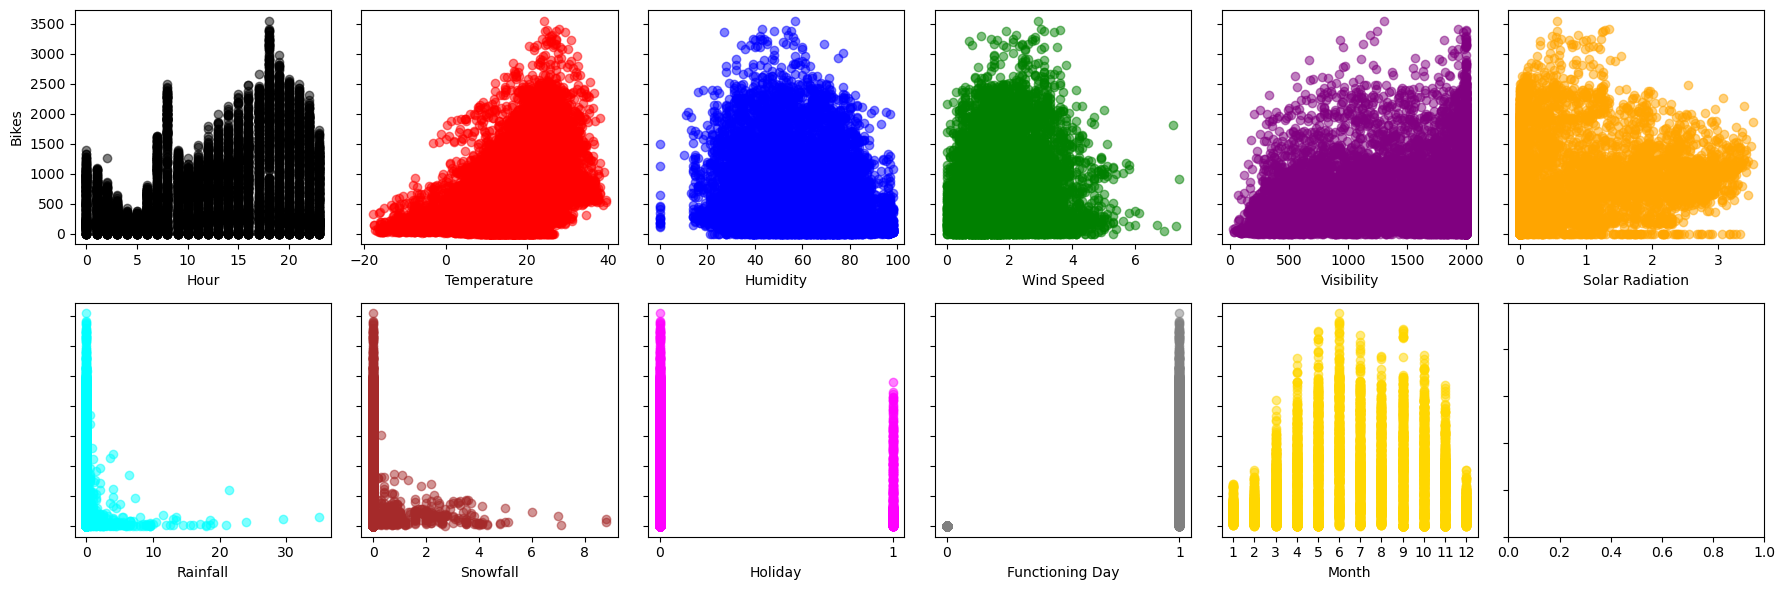

In [57]:

fig, axs = plt.subplots(2, 6, figsize=(18, 6), tight_layout=True)
axs = axs.flatten()
axs[0].scatter(hour, y, alpha=0.5, color='black' )
axs[1].scatter(temp, y, alpha=0.5, color='r' )
axs[2].scatter(humd, y, alpha=0.5, color='b' )
axs[3].scatter(wind, y, alpha=0.5, color='green')
axs[4].scatter(visi, y, alpha=0.5, color='purple')
axs[5].scatter(solr, y, alpha=0.5, color='orange')
axs[6].scatter(rain, y, alpha=0.5, color='cyan')
axs[7].scatter(snow, y, alpha=0.5, color='brown')
axs[8].scatter(hday, y, alpha=0.5, color='magenta')
axs[9].scatter(fday, y, alpha=0.5, color='gray')
axs[10].scatter(month, y, alpha=0.5, color='gold')
xlabels = 'Hour', 'Temperature', 'Humidity', 'Wind Speed', 'Visibility', 'Solar Radiation', 'Rainfall', 'Snowfall', 'Holiday', 'Functioning Day', 'Month'
[ax.set_xlabel(s) for ax,s in zip(axs,xlabels)]
axs[0].set_ylabel('Bikes')
[ax.set_yticklabels([])  for ax in axs[1:]]


axs[8].set_xticks([0, 1])
axs[9].set_xticks([0, 1])
axs[10].set_xticks(np.arange(1, 13, 1))
plt.show()

Next let's add regression lines and correlation coefficients to each plot:

In [58]:
def corrcoeff(x, y):
    r = np.corrcoef(x, y)[0,1]
    return r

def plot_regression_line(ax, x, y, **kwargs):
    a,b   = np.polyfit(x, y, deg=1)
    x0,x1 = min(x), max(x)
    y0,y1 = a*x0 + b, a*x1 + b
    ax.plot([x0,x1], [y0,y1], **kwargs)


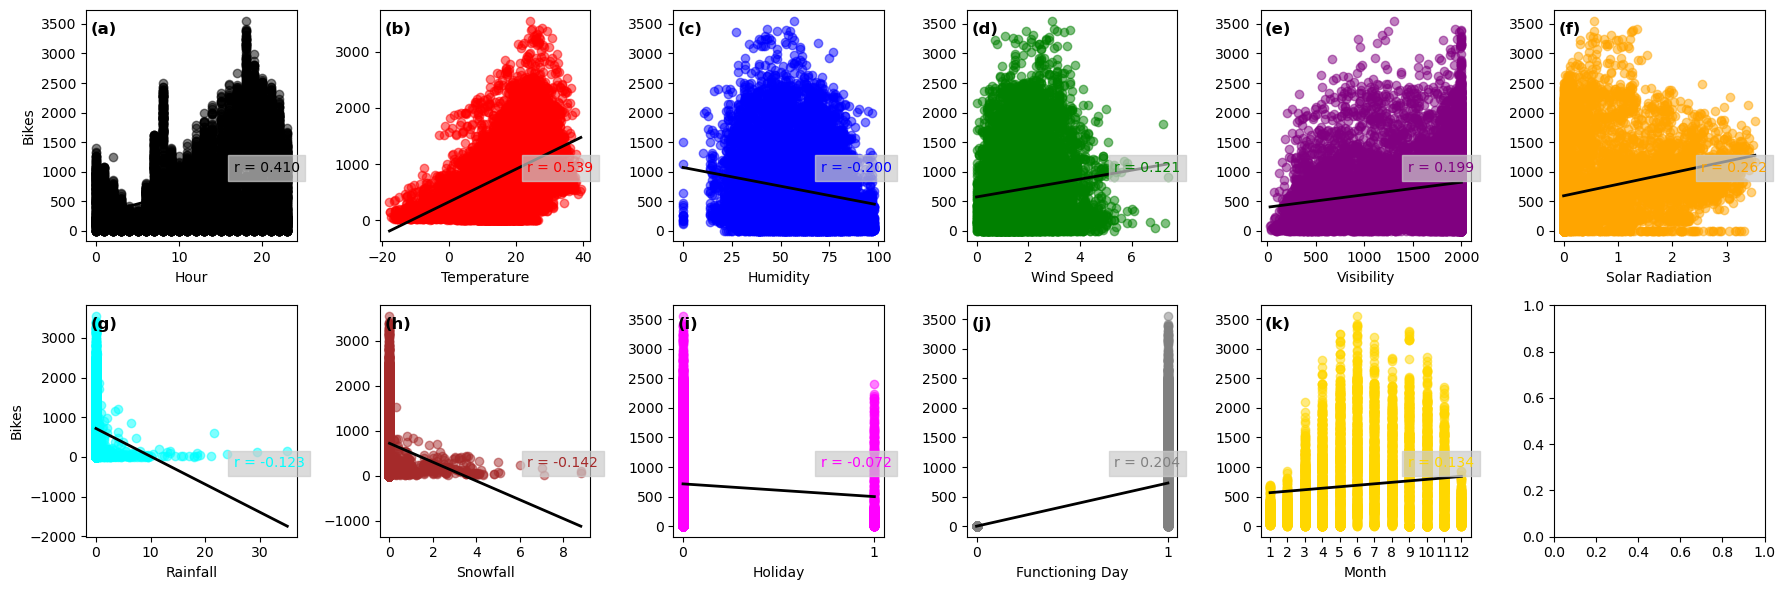

<p><span style="font-size: 1.2em;"><b>Figure 1</b>: Correlations amongst main variables.</span></p><br><br>

In [59]:
def plot_descriptive():    
    fig, axs = plt.subplots(2, 6, figsize=(18, 6), tight_layout=True)
    axs = axs.flatten()
    ivs     = [hour, temp, humd, wind, visi, solr, rain, snow, hday, fday, month]
    colors  = 'black' , 'r' , 'b' , 'green', 'purple', 'orange', 'cyan', 'brown', 'magenta', 'gray', 'gold'
    for ax,x,c in zip(axs, ivs, colors):
        ax.scatter( x, y, alpha=0.5, color=c )
        plot_regression_line(ax, x, y, color='k', ls='-', lw=2)
        r   = corrcoeff(x, y)
        ax.text(0.7, 0.3, f'r = {r:.3f}', color=c, transform=ax.transAxes, bbox=dict(color='0.8', alpha=0.7))
    
    xlabels = 'Hour', 'Temperature', 'Humidity', 'Wind Speed', 'Visibility', 'Solar Radiation', 'Rainfall', 'Snowfall', 'Holiday', 'Functioning Day', 'Month'
    [ax.set_xlabel(s) for ax,s in zip(axs,xlabels)]
    axs[0].set_ylabel('Bikes')
    axs[6].set_ylabel('Bikes')
    axs[8].set_xticks([0, 1])
    axs[9].set_xticks([0, 1])
    axs[10].set_xticks(np.arange(1, 13, 1))
    panel_labels = 'a b c d e f g h i j k'.split()

    for ax, label in zip(axs, panel_labels):
        ax.text(
            0.02, 0.95, f'({label})',
            transform=ax.transAxes,
            fontsize=12,
            fontweight='bold',
            va='top'
        )
    plt.show()
    display_title('Correlations amongst main variables.', pref='Figure', num=1)
plot_descriptive()

The correlation coefficients are all relatively low, suggesting no clear linear correlation between the DV and IVs.
At best we can say there is a weak linear correlation between the temperature and bikes rented. Some data are also not fit for linear regression analysis, such as "cyclic" data like hours, months and the binary parameters Holiday and Functioning day. We can also observe that non-functioning day do not have bikes rented.